# Day 7: Session 7A - The Anatomy of a Figure

[Session Webpage](https://eds-217-essential-python.github.io/course-materials/interactive-sessions/7a_matplotlib.html)

Date: 09/09/2026

In [2]:
import pandas as pd
import matplotlib.pyplot as plt

url = 'https://eds-217-essential-python.github.io/data/toolik_weather.csv'
toolik = pd.read_csv(url)

toolik['date'] = pd.to_datetime(toolik['Date'], format='%Y%m%d')
toolik['year'] = toolik['date'].dt.year
toolik['month'] = toolik['date'].dt.month

toolik.shape

(11171, 24)

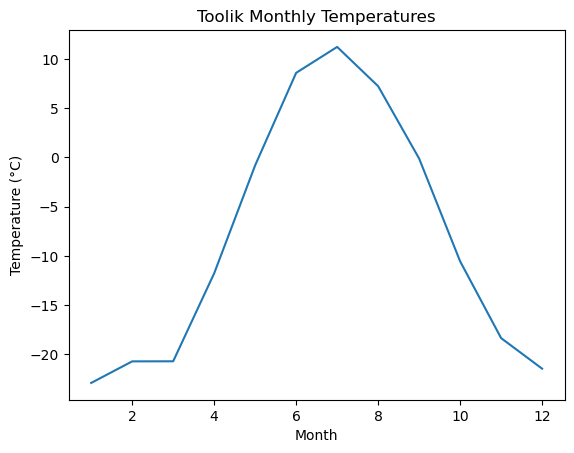

In [3]:
# rebuilding the graph of this data we made earlier this year
monthly_means = toolik.groupby('month')['Daily_AirTemp_Mean_C'].mean()

plt.plot(monthly_means)
plt.title('Toolik Monthly Temperatures')
plt.xlabel('Month')
plt.ylabel('Temperature (°C)')
plt.show()

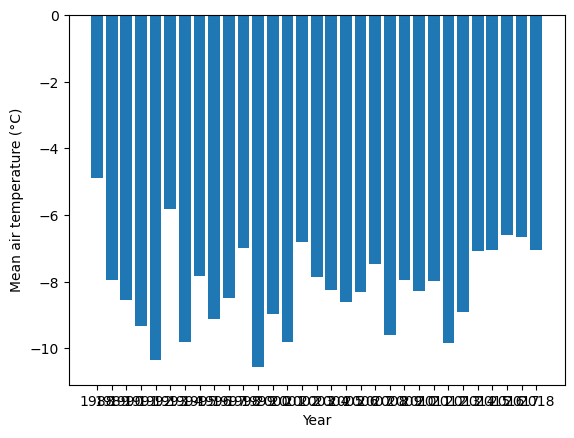

In [4]:
# sometimes the default settings aren't good for a 
# figure, here is an example
annual_means = toolik.groupby('year')['Daily_AirTemp_Mean_C'].mean()

plt.bar(annual_means.index.astype(str), annual_means)
plt.xlabel('Year')
plt.ylabel('Mean air temperature (°C)')
plt.show()

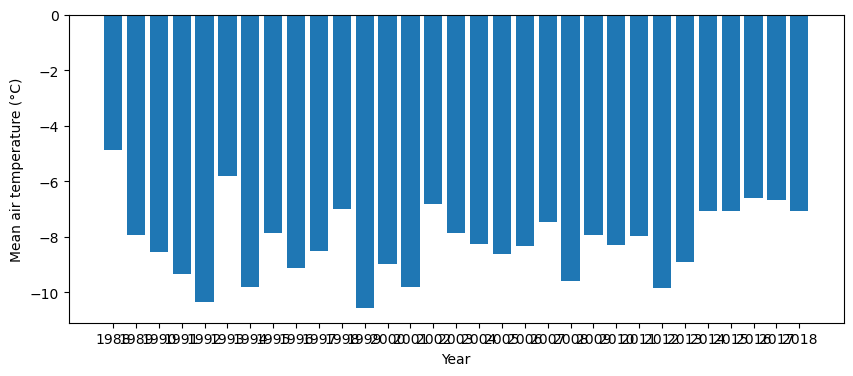

In [5]:
# BUT you can change the aspect ratio of a figure
# using the plt.figure(figsize=(width, height)) command


plt.figure(figsize=(10, 4))

plt.bar(annual_means.index.astype(str), annual_means)
plt.xlabel('Year')
plt.ylabel('Mean air temperature (°C)')
plt.show()

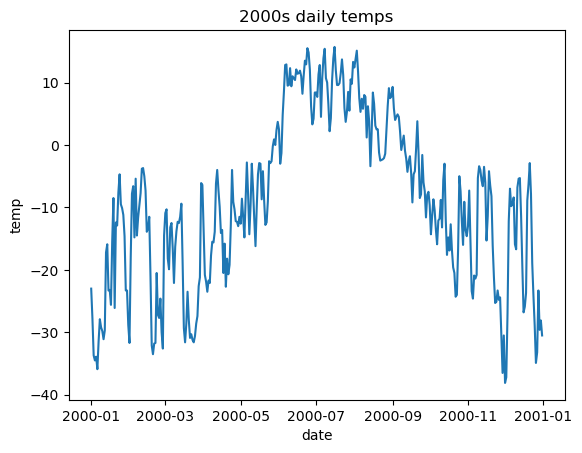

In [13]:

temp2000 = toolik[toolik['year'] == 2000][['date','Daily_AirTemp_Mean_C']]
temp2000 = temp2000.set_index('date')
temp2000
plt.plot(temp2000)
plt.title('2000s daily temps')
plt.xlabel('date')
plt.ylabel('temp')
plt.show()

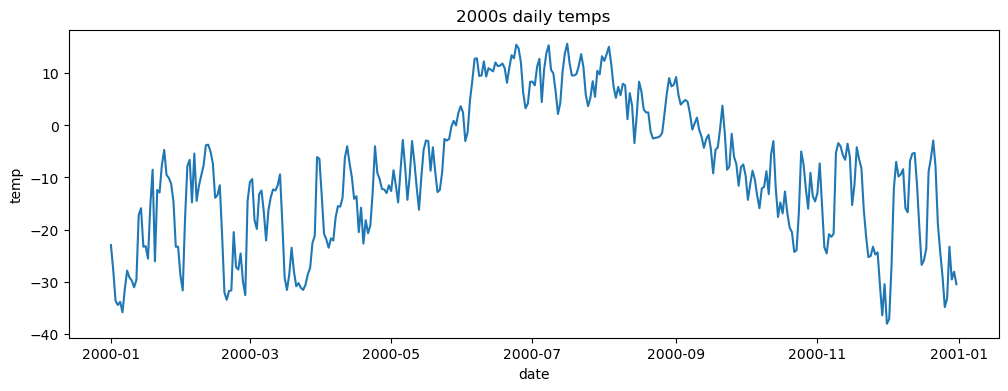

In [7]:
# redoing the plot with a plt.figure()
plt.figure(figsize=(12, 4))

plt.plot(temp2000)
plt.title('2000s daily temps')
plt.xlabel('date')
plt.ylabel('temp')
plt.show()

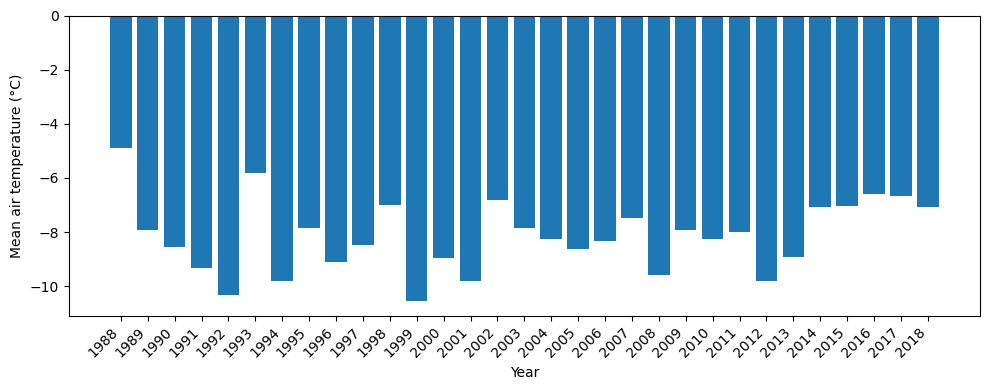

In [8]:
# what if we wanted to rotate the tick titles along the x axis?

# to rotate we use plt.xticks(rotation=45, ha='right')

plt.figure(figsize=(10, 4))

plt.bar(annual_means.index.astype(str), annual_means)
plt.xticks(rotation=45, ha='right')
plt.xlabel('Year')
plt.ylabel('Mean air temperature (°C)')
plt.tight_layout()
plt.show()

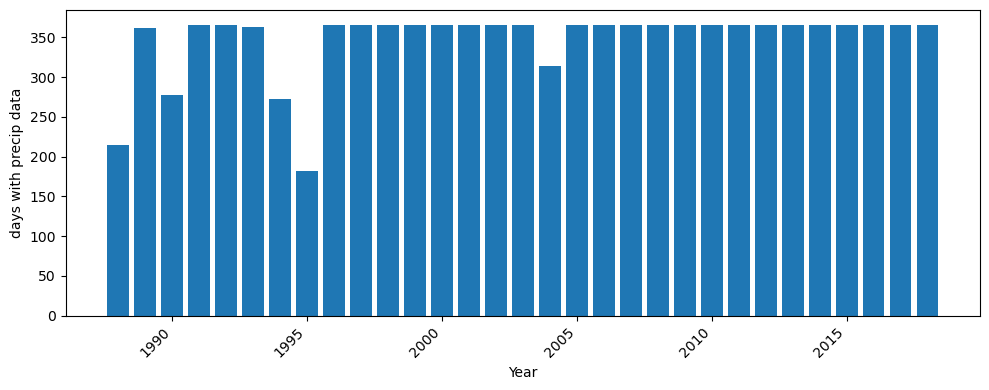

In [48]:
precipnotnull = toolik[toolik['Daily_Precip_Total_mm'].notnull()].copy()
precipnotnull = precipnotnull.groupby('year')['Daily_Precip_Total_mm'].count().copy()

plt.figure(figsize=(10, 4))

plt.bar(precipnotnull.index, precipnotnull)
plt.xticks(rotation=45, ha='right')
plt.xlabel('Year')
plt.ylabel('days with precip data')
plt.tight_layout()
plt.show()

In [45]:
# finding which years don't have 366 or 365 of rain data
precipnotnull = pd.DataFrame(precipnotnull)
precipnotnull[precipnotnull['Daily_Precip_Total_mm'] < 300]

,Daily_Precip_Total_mm
year,
1988,214
1990,277
1994,273
1995,182


In [33]:
# so lets look at two plots on one thing or something?
early = toolik[toolik['year'] <= 1998]
late = toolik[toolik['year'] >= 2009]

comparison = pd.DataFrame({
    'early': early.groupby('month')['Daily_AirTemp_Mean_C'].mean(),
    'late': late.groupby('month')['Daily_AirTemp_Mean_C'].mean(),
})

comparison['change'] = comparison['late'] - comparison['early']

comparison.round(2)

,early,late,change
month,,,
1,-24.72,-21.26,3.46
2,-21.86,-19.38,2.48
3,-18.62,-20.64,-2.02
4,-10.40,-11.86,-1.45
5,0.37,-0.54,-0.91
6,8.43,8.19,-0.24
7,12.05,11.28,-0.77
8,7.48,7.18,-0.30
9,-0.85,-0.01,0.84


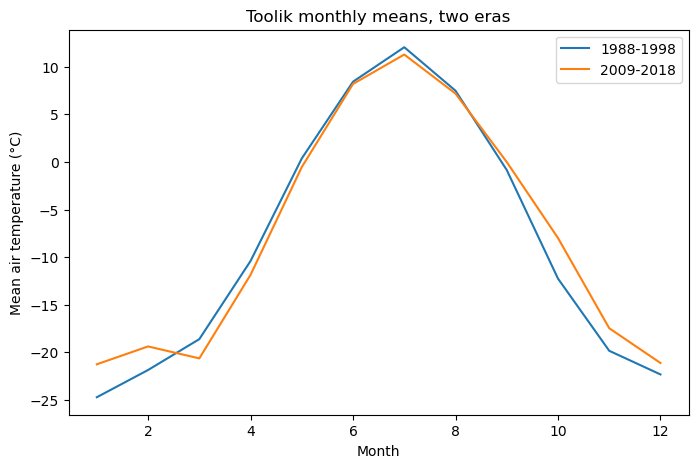

In [34]:
# above is the data we would like to double plot
# now we can plot it

plt.figure(figsize=(8, 5))

plt.plot(comparison.index, comparison['early'], label='1988-1998')
plt.plot(comparison.index, comparison['late'], label='2009-2018')

plt.xlabel('Month')
plt.ylabel('Mean air temperature (°C)')
plt.title('Toolik monthly means, two eras')
plt.legend()
plt.show()